In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('bank_churn_cleaned.csv')
df.head()

,credit_score,country,gender,age,tenure,balance,num_products,credit_card,active_member,salary,churn,churn_label,credit_card_label,active_member_label,age_group,balance_group,credit_score_group
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,Churned,Yes,Active,41-50,Zero,Fair
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Retained,No,Active,41-50,Medium,Fair
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,Churned,Yes,Inactive,41-50,High,Fair
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,Retained,No,Inactive,31-40,Zero,Good
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,Retained,Yes,Active,41-50,High,Excellent


# Bank Customer Churn - EDA

## 1. Univariate Analysis

### What is the overall churn rate?

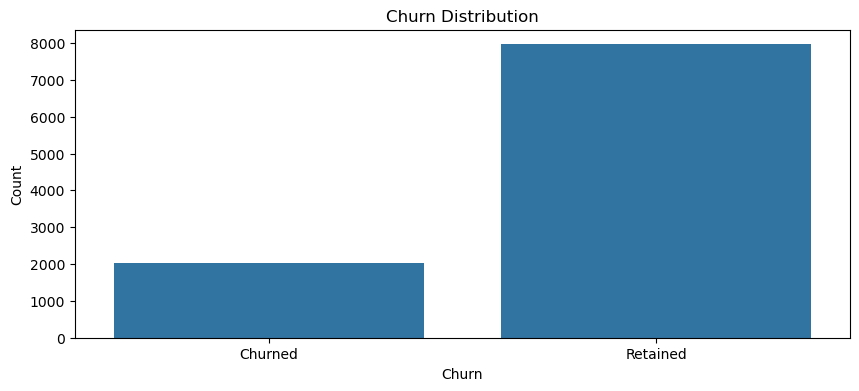

In [6]:
plt.figure(figsize = (10,4))
plt.title('Churn Distribution')
sns.countplot(df, x = 'churn_label')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

In [10]:
df['churn_label'].value_counts(normalize=True) * 100

churn_label
Retained    79.63
Churned     20.37
Name: proportion, dtype: float64

**Insight:** Approximately 20% of customers churned, indicating a class imbalance. 
Retaining churned customers should be a key business priority.

### What is the age distribution of customers?

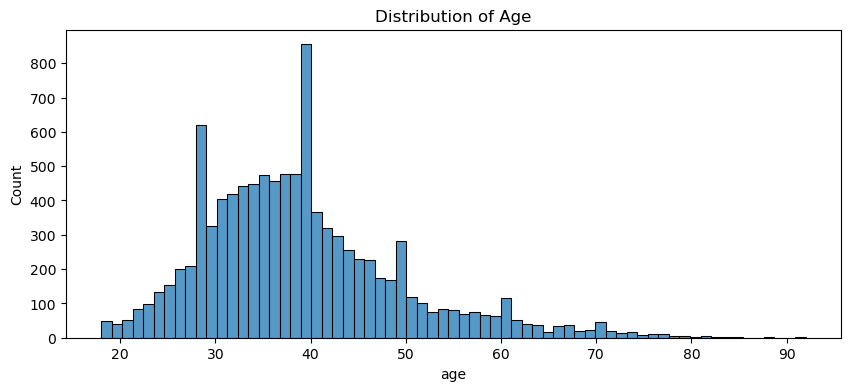

In [13]:
plt.figure(figsize = (10,4))
plt.title('Distribution of Age')
sns.histplot(df, x = 'age')
plt.show()

In [47]:
df['age_group'].value_counts(normalize=True) * 100

age_group
31-40    44.51
41-50    23.20
18-30    19.68
51-60     7.97
60+       4.64
Name: proportion, dtype: float64

**Insight:** Majority of customers are aged 31-40 (44.5%), 
followed by 41-50 (23.2%). Very few customers are above 60.

### What is the balance distribution of customers?

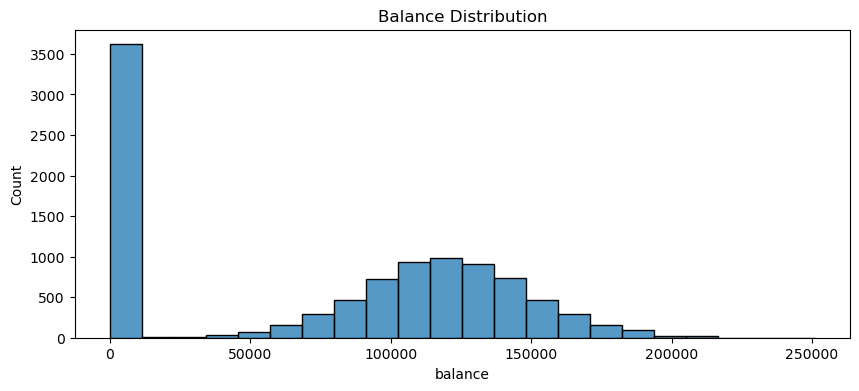

In [17]:
plt.figure(figsize = (10,4))
plt.title('Balance Distribution')
sns.histplot(df, x = 'balance')
plt.show()

**Insight:** Balance distribution is bimodal - a large portion of customers have zero balance, while the remaining cluster around 100k - 150k.
This suggests two distinct customer segment

### What is the salary distribution of customers?

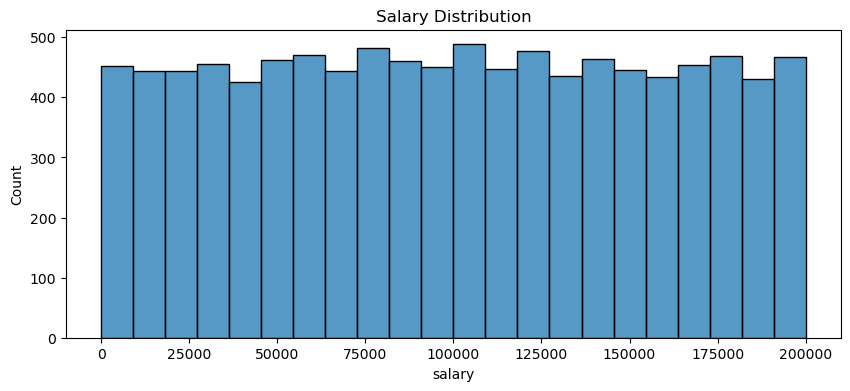

In [18]:
plt.figure(figsize = (10,4))
plt.title('Salary Distribution')
sns.histplot(df, x = 'salary')
plt.show()

**Insight:** Salary is uniformly distributed across all ranges (0-200k), 
suggesting salary alone may not be a strong predictor of churn.

### What is the country distribution of customers?

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


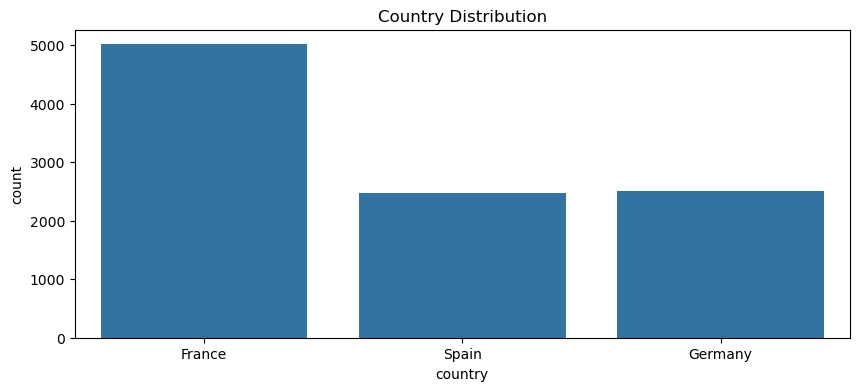

In [19]:
plt.figure(figsize = (10,4))
plt.title('Country Distribution')
sns.countplot(df, x = 'country')
plt.show()

In [20]:
df['country'].value_counts(normalize=True) * 100

country
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64

**Insight:** France has the highest customer base (50%), followed by Germany and Spain with equal shape (~25% each)

### What is the gender distribution of customers?

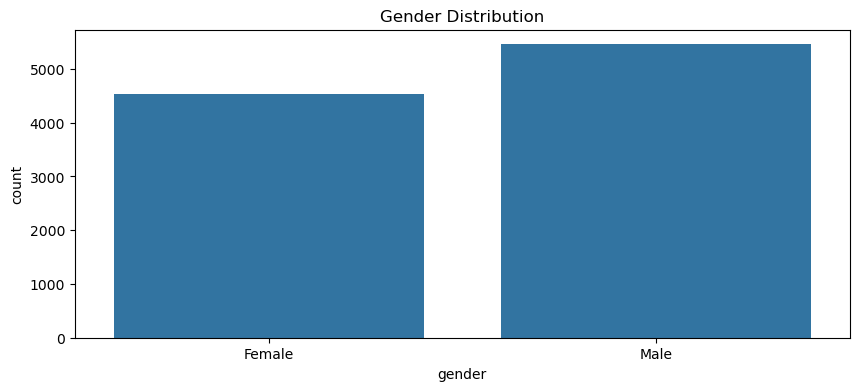

In [21]:
plt.figure(figsize = (10,4))
plt.title('Gender Distribution')
sns.countplot(df, x = 'gender')
plt.show()

In [22]:
df['gender'].value_counts(normalize=True) * 100

gender
Male      54.57
Female    45.43
Name: proportion, dtype: float64

**Insight:** Majority of the customer are male (54.6%) compare to female (45.4%). Distribution are farely balanced.

## 1. Univariate Analysis

### Do male or female customers churn more?

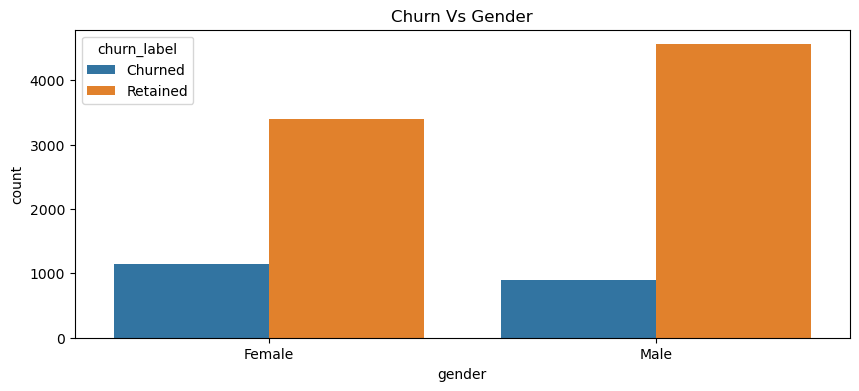

In [23]:
plt.figure(figsize = (10,4))
plt.title('Churn Vs Gender')
sns.countplot(df, x = 'gender', hue='churn_label')
plt.show()

In [24]:
df.groupby('gender')['churn'].mean()*100

gender
Female    25.071539
Male      16.455928
Name: churn, dtype: float64

**Insight:** Female customers churn significantly more (25%) comapare to male customer (16.5%). Gender appears to be an important factor in churn behavior.

### Which country has the highest churn rate?

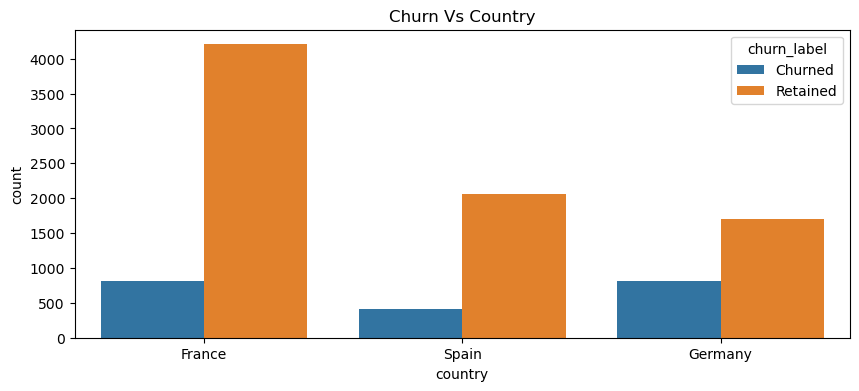

In [25]:
plt.figure(figsize = (10,4))
plt.title('Churn Vs Country')
sns.countplot(df, x = 'country', hue='churn_label')
plt.show()

In [26]:
df.groupby('country')['churn'].mean()*100

country
France     16.154767
Germany    32.443204
Spain      16.673395
Name: churn, dtype: float64

**Insight:** Germany has significantly high churn rate (32.5%) compare to Spain (16.7%) and France (16.2%). 
Germany customer are twice as likely to churn - needs business attention

### Which age group churns the most?

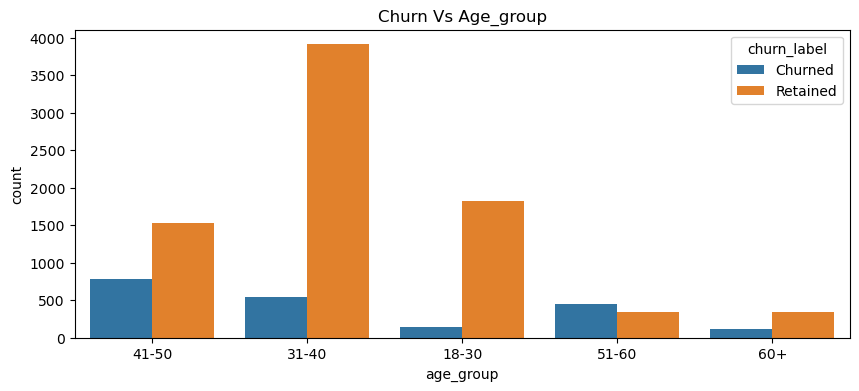

In [28]:
plt.figure(figsize = (10,4))
plt.title('Churn Vs Age_group')
sns.countplot(df, x = 'age_group', hue='churn_label')
plt.show()

In [29]:
df.groupby('age_group')['churn'].mean()*100

age_group
18-30     7.520325
31-40    12.087171
41-50    33.965517
51-60    56.210790
60+      24.784483
Name: churn, dtype: float64

**Insight:** Churn rate increase significantly with age. 51-60 age group has the highest churn rate (56.2%), followed by 41-50 (34%). Younger customers (18-30) are least likely to churn (7.5%). Age is a strong predictor of churn behavior.

### Does account balance affect churn rate?

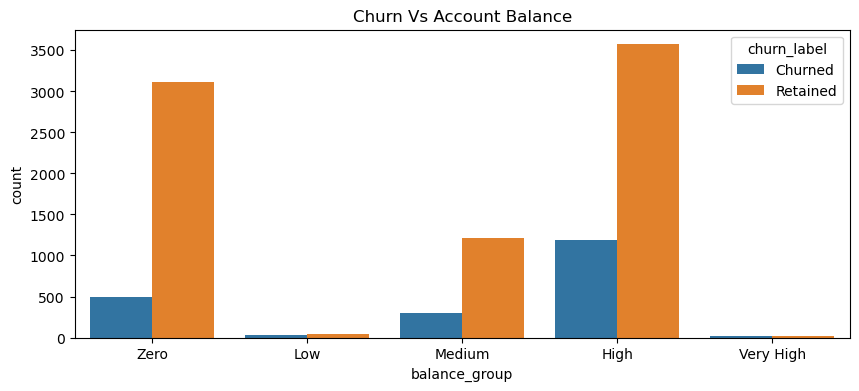

In [33]:
order = ['Zero', 'Low', 'Medium', 'High', 'Very High']
plt.figure(figsize = (10,4))
plt.title('Churn Vs Account Balance')
sns.countplot(df, x = 'balance_group', hue='churn_label', order = order)
plt.show()

In [32]:
df.groupby('balance_group')['churn'].mean()*100

balance_group
High         25.015740
Low          34.666667
Medium       19.880716
Very High    55.882353
Zero         13.823611
Name: churn, dtype: float64

**Insight:** High balance customers churn significantly more (25%) 
compared to Zero balance (13.8%). Very High balance shows 55.9% churn 
but sample size is too small to draw conclusions. 
Customers with money in account are more likely to churn — 
possibly switching to better offers elsewhere.

### Do inactive members churn more than active members?

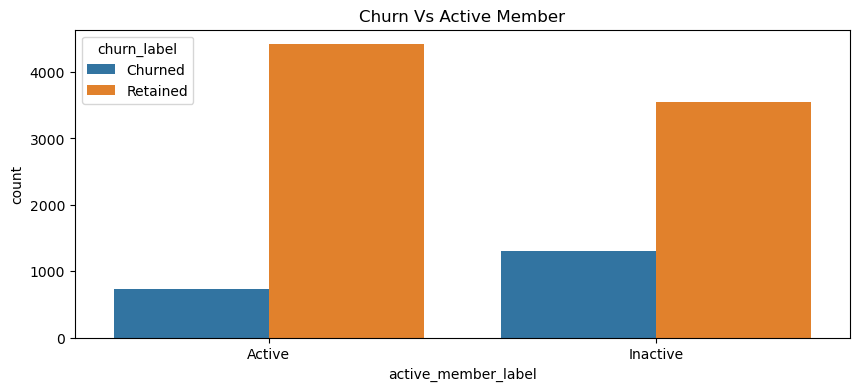

In [35]:
plt.figure(figsize = (10,4))
plt.title('Churn Vs Active Member')
sns.countplot(df, x = 'active_member_label', hue='churn_label')
plt.show()

In [36]:
df.groupby('active_member_label')['churn'].mean()*100

active_member_label
Active      14.269074
Inactive    26.850897
Name: churn, dtype: float64

**Insight:** Inactive customers churn nearly twice as much (26.9%) compare to active customer (14.3%). Keeping customers engaged is critical to reducing churn.

### Does the number of products affect churn rate?

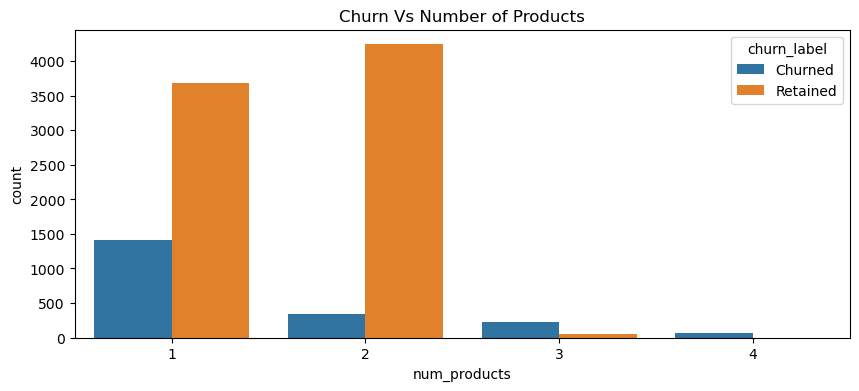

In [38]:
plt.figure(figsize = (10,4))
plt.title('Churn Vs Number of Products')
sns.countplot(df, x = 'num_products', hue='churn_label')
plt.show()

In [39]:
df.groupby('num_products')['churn'].mean()*100

num_products
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: churn, dtype: float64

**Insight:** Customers with 1 product churn at 27.7%, while 2 product 
customers are most loyal (7.6%). Customers with 3-4 products churn 
extremely high (83-100%) but sample size is very small — 
results may not be reliable. Encouraging customers to take 2 products 
could be a key retention strategy.

### Does having a credit card affect churn rate?

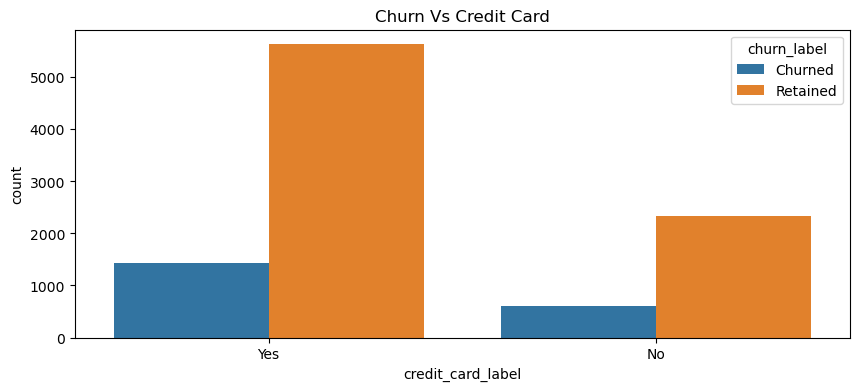

In [40]:
plt.figure(figsize = (10,4))
plt.title('Churn Vs Credit Card')
sns.countplot(df, x = 'credit_card_label', hue='churn_label')
plt.show()

In [41]:
df.groupby('credit_card_label')['churn'].mean()*100

credit_card_label
No     20.814941
Yes    20.184266
Name: churn, dtype: float64

**Insight:** Credit card ownership has almost no effect on churn rate 
(No: 20.8%, Yes: 20.2%). Credit card is not a significant factor in churn behavior.

### Does having a credit score affect churn rate?

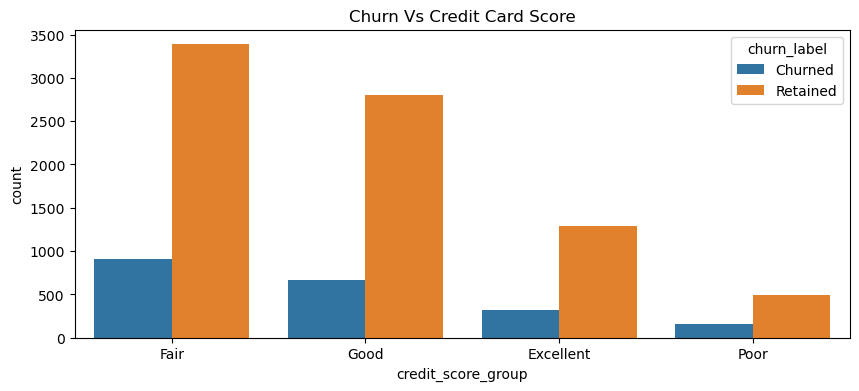

In [46]:
plt.figure(figsize = (10,4))
plt.title('Churn Vs Credit Card Score')
sns.countplot(df, x = 'credit_score_group', hue='churn_label')
plt.show()

In [45]:
df.groupby('credit_score_group')['churn'].mean()*100

credit_score_group
Excellent    19.586984
Fair         21.075920
Good         19.249639
Poor         23.639191
Name: churn, dtype: float64

**Insight:** Poor credit score customers churn slightly more (23.6%) 
compared to Excellent (19.6%). However, the difference is small — 
credit score is not a strong predictor of churn.

## 3.Correlation Heatmap

### How are numeric features correlated with each other?

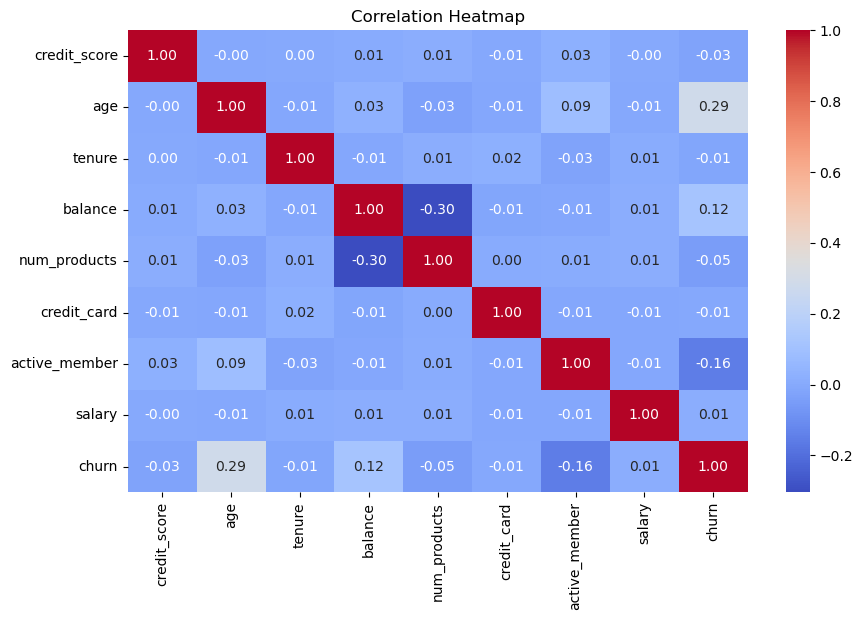

In [43]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize = (10,6))
plt.title('Correlation Heatmap')
sns.heatmap(numeric_df.corr(), annot = True, fmt = '.2f', cmap = 'coolwarm')
plt.show()

**Insight:** 
- Age has the strongest positive correlation with churn (0.29) — 
  older customers churn more.
- Active member has negative correlation with churn (-0.16) — 
  active members churn less.
- Balance & num_products are negatively correlated (-0.30) — 
  more products means lower balance.
- Salary and credit_score have almost no correlation with churn — 
  confirming earlier findings.